In [ ]:
import pandas as pd
df=pd.read_csv("dems.csv")
df.head()

,Group,MR Delay,SES,MMSE,CDR
0,0,0,2,27,0.0
1,0,457,2,30,0.0
2,0,0,3,28,0.0
3,0,538,3,27,0.0
4,0,0,4,28,0.0


In [ ]:
!pip install qiskit scikit-learn matplotlib --quiet

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
import matplotlib.pyplot as plt

from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer.primitives import Sampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# Set seed for reproducibility
seed = 45

# ---------------------------
# Load data (your file)
# ---------------------------
df = pd.read_csv('dems.csv')
X = df.drop('Group', axis=1)
y = df['Group']

print("Found class labels (unique):", sorted(y.unique()))

# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# ---------------------------
# OPTIONAL scaling (uncomment if needed)
# ---------------------------
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# ---------------------------
# Feature map: automatically set dimension to number of features
# WARNING: quantum circuits grow quickly with feature_dimension
# ---------------------------
adhoc_dimension = X_train.shape[1]
if adhoc_dimension != 2:
    print(f"Note: setting feature_dimension = {adhoc_dimension} (number of features).")
    if adhoc_dimension > 12:
        print("Warning: large feature_dimension (>12) can create very large quantum circuits and slow runs.")

feature_map = ZZFeatureMap(feature_dimension=adhoc_dimension, insert_barriers=True, reps=3, entanglement='full')
sampler = Sampler()
adhoc_kernel = FidelityQuantumKernel(feature_map=feature_map)

# ---------------------------
# Train QSVC
# ---------------------------
qsvc = QSVC(quantum_kernel=adhoc_kernel)

print("Training QSVC...")
qsvc.fit(X_train, y_train.values.ravel())
print("Training finished.")

# ---------------------------
# Predictions & metrics (Quantum)
# ---------------------------
y_pred_qsvc = qsvc.predict(X_test)

acc_qsvc = accuracy_score(y_test, y_pred_qsvc)
print(f"\nQSVC test accuracy: {acc_qsvc:.4f}\n")

# Classification report (precision, recall, f1 per class + support)
print("QSVC Classification Report:")
print(classification_report(y_test, y_pred_qsvc, digits=4))

# Aggregated metrics
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred_qsvc, average='macro')
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred_qsvc, average='weighted')
print("Aggregated metrics:")
print(f" Macro Avg -> Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
print(f" Weighted -> Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")

# Confusion Matrix (numbers + plot)
cm = confusion_matrix(y_test, y_pred_qsvc, labels=qsvc.classes_)
print("\nQSVC Confusion Matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm, index=qsvc.classes_, columns=qsvc.classes_))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=qsvc.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("QSVC Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Compare with classical SVM
# ---------------------------
print("\nComparing with a classical SVM (RBF kernel)...")
classical_svm = SVC(kernel='rbf', probability=False, random_state=seed)
classical_svm.fit(X_train, y_train)
y_pred_classic = classical_svm.predict(X_test)
acc_classic = accuracy_score(y_test, y_pred_classic)
print(f"Classical SVM test accuracy: {acc_classic:.4f}\n")

print("Classical SVM Classification Report:")
print(classification_report(y_test, y_pred_classic, digits=4))

cm2 = confusion_matrix(y_test, y_pred_classic, labels=classical_svm.classes_)
print("\nClassical SVM Confusion Matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm2, index=classical_svm.classes_, columns=classical_svm.classes_))

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classical_svm.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp2.plot(ax=ax, xticks_rotation='vertical')
plt.title("Classical SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Optional: ROC & PR curves if binary classification
# ---------------------------
unique_classes = np.unique(y_train)
if len(unique_classes) == 2:
    print("\nBinary classification detected — plotting ROC and Precision-Recall curves.")
    # binarize labels in the test set according to qsvc.classes_
    y_test_bin = label_binarize(y_test, classes=qsvc.classes_).ravel()
    # For QSVC: try decision_function (if available) else fallback to predict_proba (not available for QSVC)
    try:
        scores_q = qsvc.decision_function(X_test)
    except Exception:
        # fallback: map predicted labels to scores (less informative)
        scores_q = qsvc.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin, scores_q)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f'QSVC ROC (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('QSVC ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_bin, scores_q)
    pr_auc = auc(recall_vals, precision_vals)
    plt.figure()
    plt.plot(recall_vals, precision_vals, lw=2, label=f'PR (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('QSVC Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.show()
else:
    print("\nROC / PR curves skipped (not binary classification).")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.1 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'qiskit_aer'

In [ ]:
!pip install qiskit scikit-learn matplotlib --quiet

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
import matplotlib.pyplot as plt

from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer.primitives import Sampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# Set seed for reproducibility
seed = 45

# ---------------------------
# Load data (your file)
# ---------------------------
df = pd.read_csv('dems.csv')
X = df.drop('Group', axis=1)
y = df['Group']

print("Found class labels (unique):", sorted(y.unique()))

# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# ---------------------------
# OPTIONAL scaling (uncomment if needed)
# ---------------------------
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# ---------------------------
# Feature map: automatically set dimension to number of features
# WARNING: quantum circuits grow quickly with feature_dimension
# ---------------------------
adhoc_dimension = X_train.shape[1]
if adhoc_dimension != 2:
    print(f"Note: setting feature_dimension = {adhoc_dimension} (number of features).")
    if adhoc_dimension > 12:
        print("Warning: large feature_dimension (>12) can create very large quantum circuits and slow runs.")

feature_map = ZZFeatureMap(feature_dimension=adhoc_dimension, insert_barriers=True, reps=3, entanglement='full')
sampler = Sampler()
adhoc_kernel = FidelityQuantumKernel(feature_map=feature_map)

# ---------------------------
# Train QSVC
# ---------------------------
qsvc = QSVC(quantum_kernel=adhoc_kernel)

print("Training QSVC...")
qsvc.fit(X_train, y_train.values.ravel())
print("Training finished.")

# ---------------------------
# Predictions & metrics (Quantum)
# ---------------------------
y_pred_qsvc = qsvc.predict(X_test)

acc_qsvc = accuracy_score(y_test, y_pred_qsvc)
print(f"\nQSVC test accuracy: {acc_qsvc:.4f}\n")

# Classification report (precision, recall, f1 per class + support)
print("QSVC Classification Report:")
print(classification_report(y_test, y_pred_qsvc, digits=4))

# Aggregated metrics
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred_qsvc, average='macro')
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred_qsvc, average='weighted')
print("Aggregated metrics:")
print(f" Macro Avg -> Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
print(f" Weighted -> Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")

# Confusion Matrix (numbers + plot)
cm = confusion_matrix(y_test, y_pred_qsvc, labels=qsvc.classes_)
print("\nQSVC Confusion Matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm, index=qsvc.classes_, columns=qsvc.classes_))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=qsvc.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("QSVC Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Compare with classical SVM
# ---------------------------
print("\nComparing with a classical SVM (RBF kernel)...")
classical_svm = SVC(kernel='rbf', probability=False, random_state=seed)
classical_svm.fit(X_train, y_train)
y_pred_classic = classical_svm.predict(X_test)
acc_classic = accuracy_score(y_test, y_pred_classic)
print(f"Classical SVM test accuracy: {acc_classic:.4f}\n")

print("Classical SVM Classification Report:")
print(classification_report(y_test, y_pred_classic, digits=4))

cm2 = confusion_matrix(y_test, y_pred_classic, labels=classical_svm.classes_)
print("\nClassical SVM Confusion Matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm2, index=classical_svm.classes_, columns=classical_svm.classes_))

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classical_svm.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp2.plot(ax=ax, xticks_rotation='vertical')
plt.title("Classical SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Optional: ROC & PR curves if binary classification
# ---------------------------
unique_classes = np.unique(y_train)
if len(unique_classes) == 2:
    print("\nBinary classification detected — plotting ROC and Precision-Recall curves.")
    # binarize labels in the test set according to qsvc.classes_
    y_test_bin = label_binarize(y_test, classes=qsvc.classes_).ravel()
    # For QSVC: try decision_function (if available) else fallback to predict_proba (not available for QSVC)
    try:
        scores_q = qsvc.decision_function(X_test)
    except Exception:
        # fallback: map predicted labels to scores (less informative)
        scores_q = qsvc.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin, scores_q)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f'QSVC ROC (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('QSVC ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_bin, scores_q)
    pr_auc = auc(recall_vals, precision_vals)
    plt.figure()
    plt.plot(recall_vals, precision_vals, lw=2, label=f'PR (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('QSVC Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.show()
else:
    print("\nROC / PR curves skipped (not binary classification).")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.0 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'qiskit_aer'

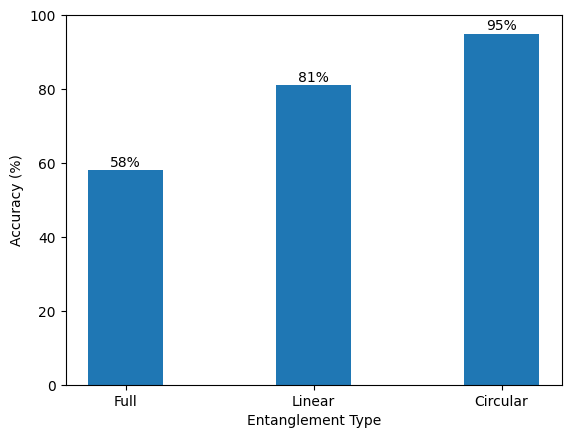

In [ ]:
import matplotlib.pyplot as plt

# Data for Graph 1
feature_maps = ['Full', 'Linear', 'Circular']
accuracy_1 = [58, 81, 95]

# Plot
plt.figure()
plt.bar(feature_maps, accuracy_1, width=0.4)  # Reduced width here
plt.xlabel('Entanglement Type')
plt.ylabel('Accuracy (%)')
plt.title('')

# Add accuracy labels
for i, v in enumerate(accuracy_1):
    plt.text(i, v + 1, f"{v}%", ha='center')

plt.ylim(0, 100)
plt.show()

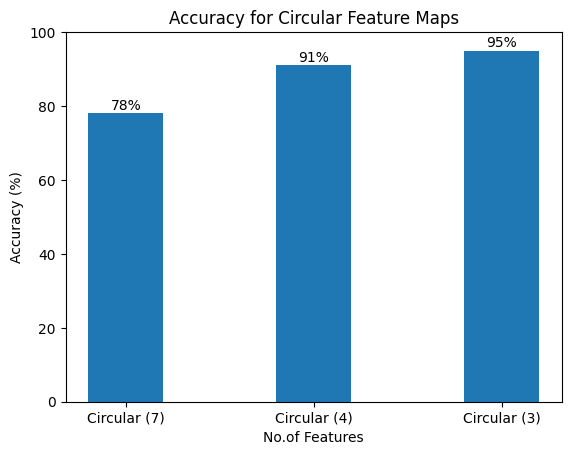

In [ ]:
import matplotlib.pyplot as plt

# Data for Graph 2
circular_maps = ['Circular (7)', 'Circular (4)', 'Circular (3)']
accuracy_2 = [78, 91, 95]

# Plot
plt.figure()
plt.bar(circular_maps, accuracy_2, width=0.4)  # Reduced width
plt.xlabel('No.of Features')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy for Circular Feature Maps')

# Add accuracy labels
for i, v in enumerate(accuracy_2):
    plt.text(i, v + 1, f"{v}%", ha='center')

plt.ylim(0, 100)
plt.show()

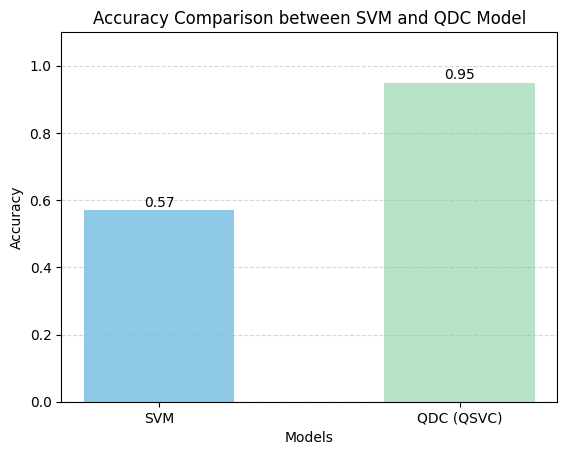

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['SVM', 'QDC (QSVC)']
accuracy = [0.57, 0.95]

# Positions (reduce spacing)
x = np.array([0, 0.6])   # closer bars

# Colors
colors = ['#8ecae6', '#b7e4c7']

# Plot
plt.figure()
plt.bar(x, accuracy, width=0.3, color=colors)

# Labels
plt.xticks(x, models)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison between SVM and QDC Model')

# Values on bars
for i, v in enumerate(accuracy):
    plt.text(x[i], v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

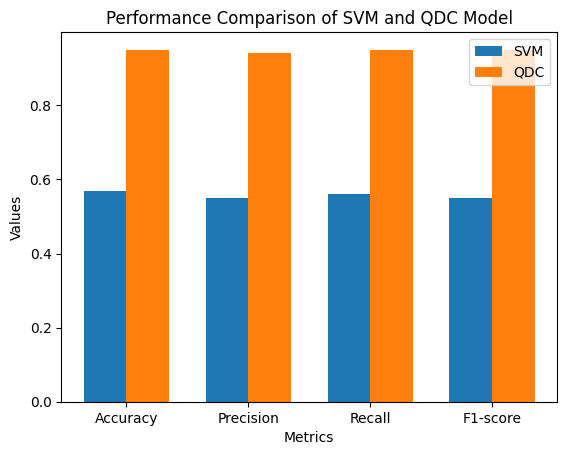

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Values (example based on your results)
svm = [0.57, 0.55, 0.56, 0.55]
qdc = [0.95, 0.94, 0.95, 0.95]

x = np.arange(len(metrics))
width = 0.35

plt.figure()
plt.bar(x - width/2, svm, width, label='SVM')
plt.bar(x + width/2, qdc, width, label='QDC')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Performance Comparison of SVM and QDC Model')
plt.xticks(x, metrics)
plt.legend()

plt.show()